Saved sequence plot to 'plots/chronological_attack_sequence_across_nodes.png'


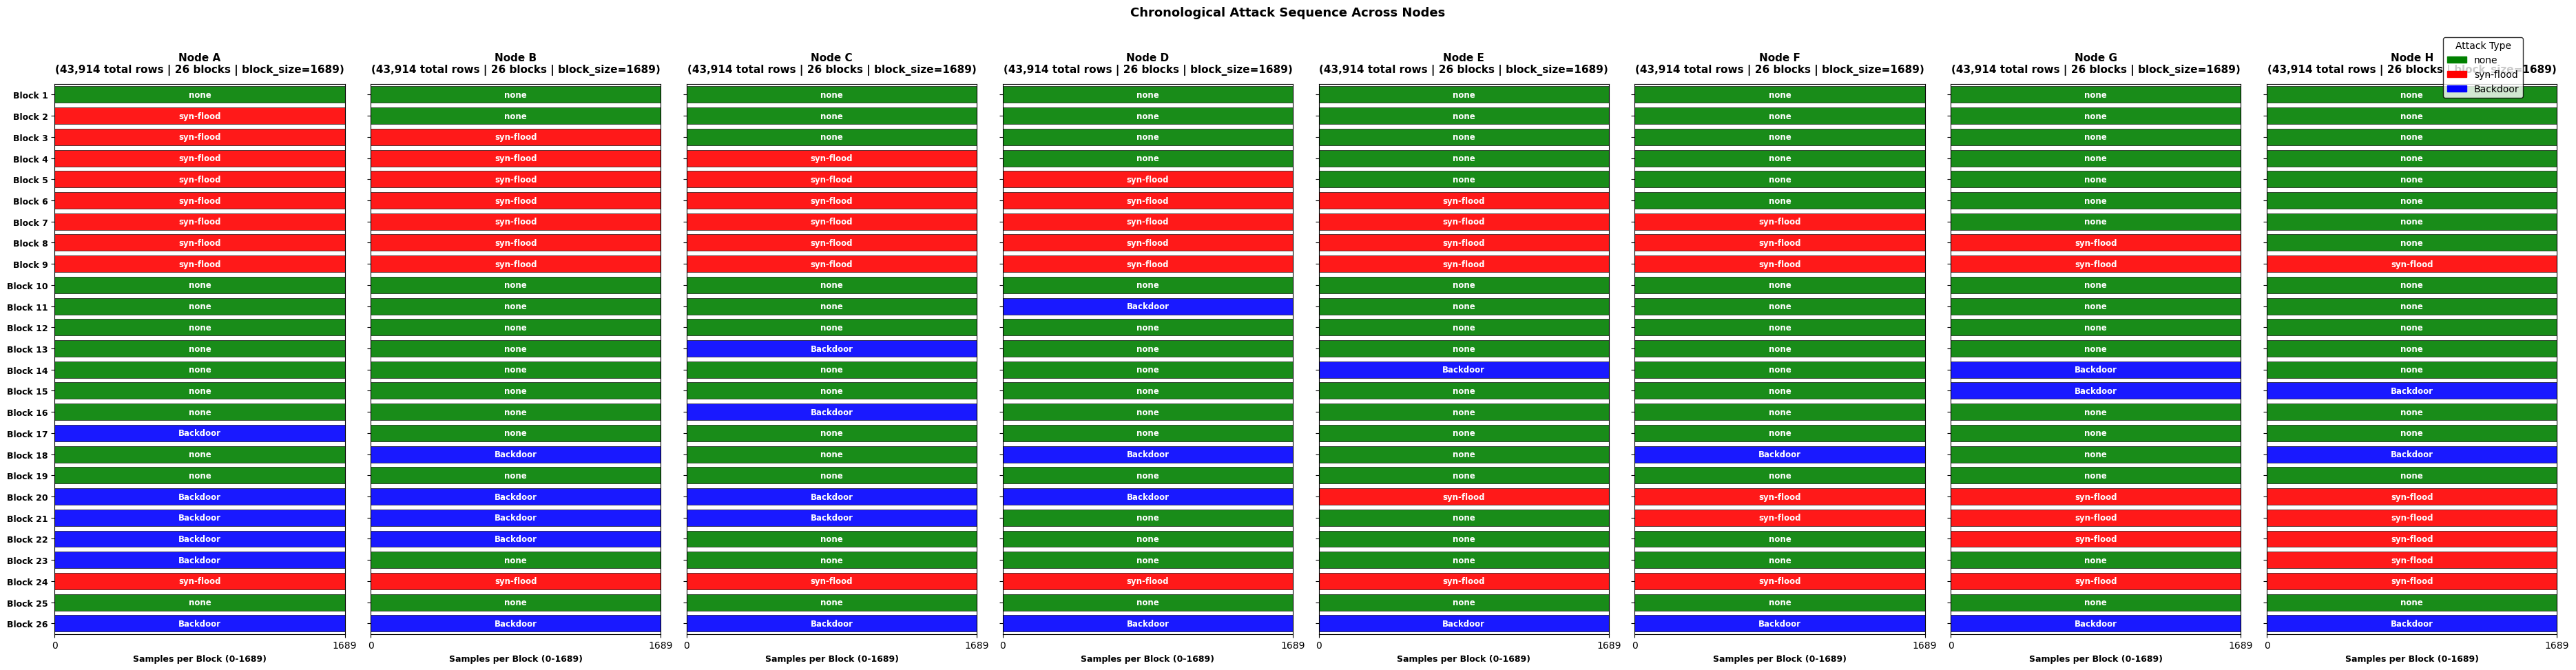

In [1]:
from pathlib import Path
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# =============================================================================
# 1. NODE CONFIGURATION, PATHS & OUTPUT DIRECTORY
# =============================================================================

OUTPUT_DIR = Path("plots")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Map all nodes (A to H) to their respective CSV files
NODE_FILES = {
    "Node A": "dataset/Node_A_final_synthetic_dataset_with_source.csv",
    "Train A": "dataset/normalized/Node_A_train.csv",
    "Test A":  "dataset/normalized/Node_A_test.csv",
    
    "Node B": "dataset/Node_B_final_synthetic_dataset_with_source.csv",
    "Train B": "dataset/normalized/Node_B_train.csv",
    "Test B":  "dataset/normalized/Node_B_test.csv",
    
    "Node C": "dataset/Node_C_final_synthetic_dataset_with_source.csv",
    "Train C": "dataset/normalized/Node_C_train.csv",
    "Test C":  "dataset/normalized/Node_C_test.csv",
    
    "Node D": "dataset/Node_D_final_synthetic_dataset_with_source.csv",
    "Train D": "dataset/normalized/Node_D_train.csv",
    "Test D":  "dataset/normalized/Node_D_test.csv",
    
    "Node E": "dataset/Node_E_final_synthetic_dataset_with_source.csv",
    "Train E": "dataset/normalized/Node_E_train.csv",
    "Test E":  "dataset/normalized/Node_E_test.csv",
    
    "Node F": "dataset/Node_F_final_synthetic_dataset_with_source.csv",
    "Train F": "dataset/normalized/Node_F_train.csv",
    "Test F":  "dataset/normalized/Node_F_test.csv",
    
    "Node G": "dataset/Node_G_final_synthetic_dataset_with_source.csv",
    "Train G": "dataset/normalized/Node_G_train.csv",
    "Test G":  "dataset/normalized/Node_G_test.csv",
    
    "Node H": "dataset/Node_H_final_synthetic_dataset_with_source.csv",
    "Train H": "dataset/normalized/Node_H_train.csv",
    "Test H":  "dataset/normalized/Node_H_test.csv",
}

# Select which nodes to display
ACTIVE_NODES = ["Node A", "Node B", "Node C", "Node D", "Node E", "Node F", "Node G", "Node H"]

ATTACK_PALETTE = {
    "none": "green",
    "syn-flood": "red",
    "Backdoor": "blue",
}

# =============================================================================
# 2. PLOT CHRONOLOGICAL SEQUENCE PER NODE
# =============================================================================
n_nodes = len(ACTIVE_NODES)
fig, axes = plt.subplots(
    nrows=1, 
    ncols=n_nodes, 
    figsize=(4.5 * n_nodes + 1.5, 9.5), 
    sharey=True
)

# Ensure axes is iterable even if only 1 node is active
if n_nodes == 1:
    axes = [axes]

max_blocks = 0

for ax, node_name in zip(axes, ACTIVE_NODES):
    file_path = Path(NODE_FILES[node_name])
    
    if not file_path.exists():
        ax.set_title(f"{node_name}\n(File not found)", fontsize=11, fontweight="bold", color="red")
        continue

    df = pd.read_csv(file_path)
    total_rows = len(df)
    
    # Infer block size from total rows / 26
    n_blocks_expected = 26
    block_size = total_rows / n_blocks_expected
    
    if not block_size.is_integer():
        print(f"Warning: {node_name} has {total_rows} rows, not perfectly divisible by 26. "
              f"Using block_size = {int(block_size)} (floor).")
        block_size = int(block_size)
    else:
        block_size = int(block_size)
    
    df["row_index"] = np.arange(total_rows)
    df["block_id"] = df["row_index"] // block_size
    n_blocks = df["block_id"].nunique()
    max_blocks = max(max_blocks, n_blocks)

    # Draw blocks top-to-bottom
    for b in range(n_blocks):
        block_data = df[df["block_id"] == b]
        attack_type = block_data["Attack"].mode()[0]
        color = ATTACK_PALETTE.get(attack_type, "gray")
        actual_block_rows = len(block_data)

        ax.barh(
            y=b,
            width=actual_block_rows,
            height=0.78,
            color=color,
            edgecolor="black",
            linewidth=0.5,
            alpha=0.9,
        )
        
        # Center label inside block
        ax.text(
            x=actual_block_rows / 2,
            y=b,
            s=attack_type,
            color="white",
            ha="center",
            va="center",
            fontsize=8.5,
            fontweight="bold",
        )

    # Invert Y-axis so Block 1 is in the top-left
    ax.set_ylim(n_blocks - 0.5, -0.5)
    ax.set_xlim(0, block_size)
    ax.set_xticks([0, block_size])
    ax.set_xlabel(f"Samples per Block (0-{block_size})", fontsize=9, fontweight="bold")
    
    # Subplot Title with Total Rows
    ax.set_title(
        f"{node_name}\n({total_rows:,} total rows | {n_blocks} blocks | block_size={block_size})", 
        fontsize=11, 
        fontweight="bold", 
        pad=12
    )

# Y-axis block labels on the leftmost subplot
if max_blocks > 0:
    axes[0].set_yticks(range(max_blocks))
    axes[0].set_yticklabels([f"Block {b+1}" for b in range(max_blocks)], fontsize=9, fontweight="bold")

# Shared Legend
legend_handles = [
    mpatches.Patch(color="green", label="none"),
    mpatches.Patch(color="red", label="syn-flood"),
    mpatches.Patch(color="blue", label="Backdoor"),
]
fig.legend(
    handles=legend_handles,
    title="Attack Type",
    loc="upper right",
    bbox_to_anchor=(0.98, 0.98),
    frameon=True,
    facecolor="white",
    edgecolor="black"
)

plt.suptitle("Chronological Attack Sequence Across Nodes", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()

# Save the plot
output_file = OUTPUT_DIR / "chronological_attack_sequence_across_nodes.png"
fig.savefig(output_file, dpi=300, bbox_inches="tight")
print(f"Saved sequence plot to '{output_file}'")

plt.show()
plt.close(fig)